# Funciones de Activación

En este laboratorio vamos a comparar algunas funciones de activación, en particular lo que queremos observar es tanto el comportamiento de la función en sí como el comportamiento de su derivada.

### SETUP

In [2]:
!pip install -q numpy==2.0.2
!pip install -q matplotlib==3.9.2

In [3]:
import numpy as np
import matplotlib.pyplot as plt

## Definición de funciones

Las funciones que vamos a evaluar son la sigmoide, ReLU y tangente hiperbólica, definamos entonces su comportamiento y derivadas para poder calcular sus gradientes 

In [14]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    return sigmoid(z) * (1 - sigmoid(z))

def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return np.where(z > 0, 1, 0)

def tanh(z):
    return (np.exp(z) - np.exp(-z))/(np.exp(z) + np.exp(-z))

def tanh_derivative(z):
    return 1- tanh(z) ** 2

## Generación de Dataset

Armemos un "Dataset" sintético para calcular los gradientes. En particular definimos un arreglo con valores ordenados y equitativamente separados entre -10 y 10 para ver el comportamiento.

In [15]:
z = np.linspace(-10, 10, 400)

## Aplicación de las Funciones

Ahora sí, veamos el comportamiento de las funciones y sus derivadas, recordemos que ambas cosas son utilizadas en el contexto del aprendizaje profundo (la función en sí para el forward pass y su derivada para el backpropagation).

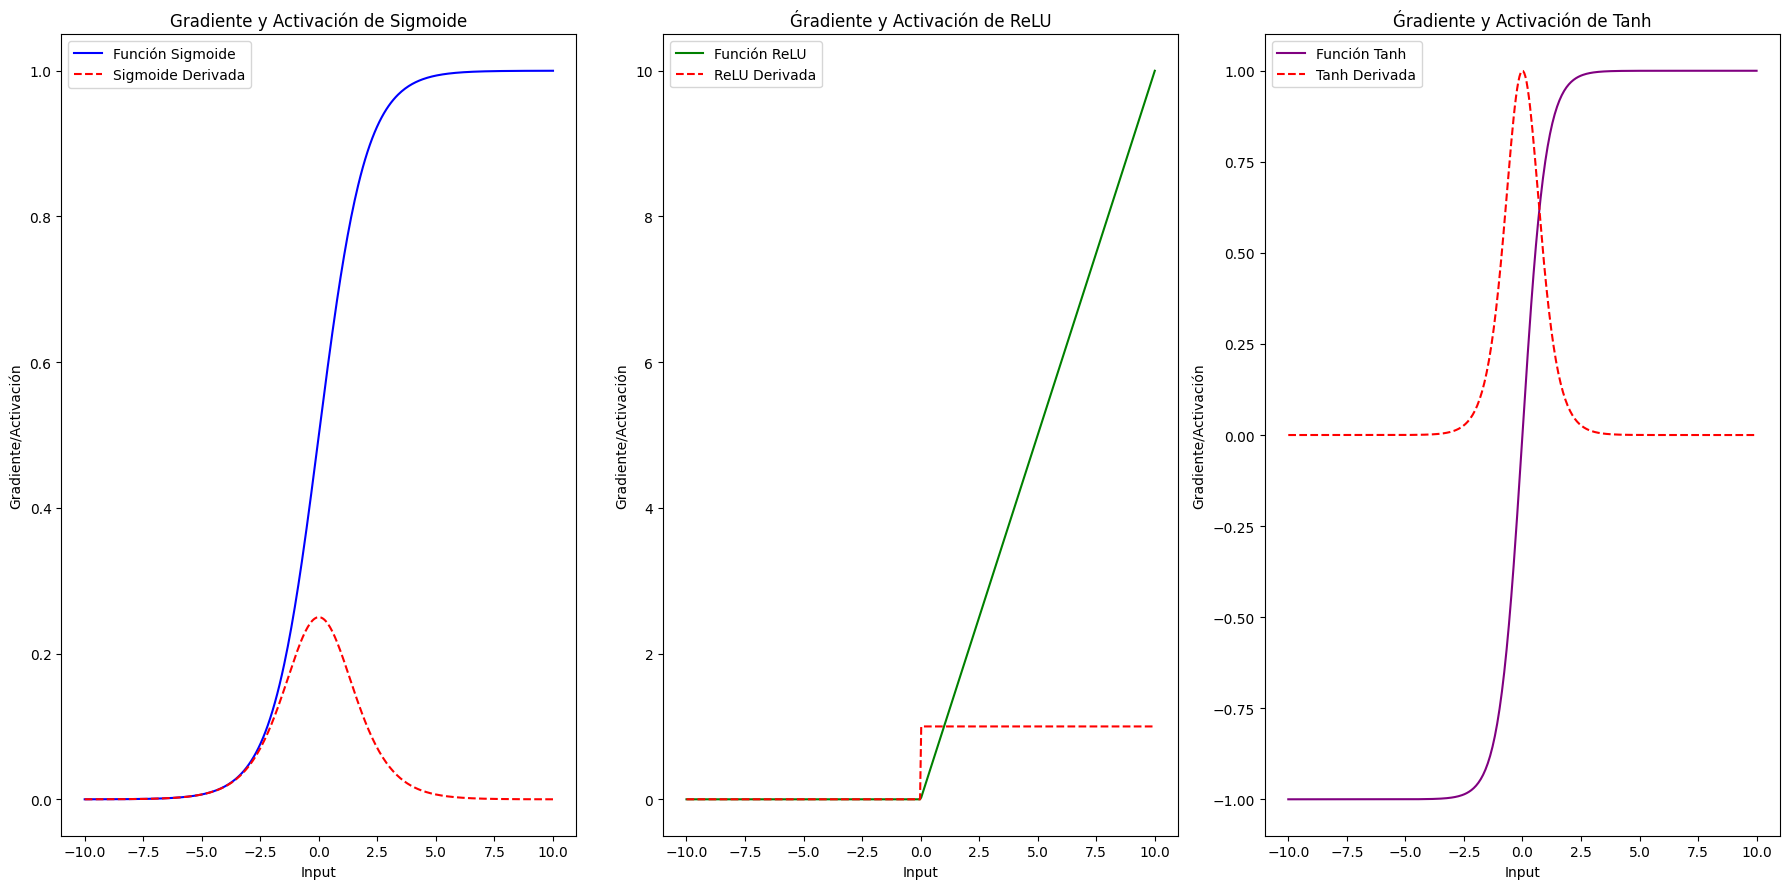

In [21]:
sigmoid_grad = sigmoid_derivative(z)

relu_grad = relu_derivative(z)

tanh_grad = tanh_derivative(z)
# Plot of activation functions

plt.figure(figsize=(18, 9))

# Plot Sigmoid and derivative
plt.subplot(1, 3, 1)
plt.plot(z, sigmoid(z), label='Función Sigmoide', color='b')
plt.plot(z, sigmoid_grad, label="Sigmoide Derivada", color='r', linestyle='--')
plt.title('Gradiente y Activación de Sigmoide')
plt.xlabel('Input')
plt.ylabel('Gradiente/Activación')
plt.legend()

# Plot ReLU and derivative
plt.subplot(1, 3, 2)
plt.plot(z, relu(z), label='Función ReLU', color='g')
plt.plot(z, relu_grad, label="ReLU Derivada", color='r', linestyle='--')
plt.title('Ǵradiente y Activación de ReLU')
plt.xlabel('Input')
plt.ylabel('Gradiente/Activación')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(z, tanh(z), label='Función Tanh', color='purple')
plt.plot(z, tanh_grad, label="Tanh Derivada", color='r', linestyle='--')
plt.title('Ǵradiente y Activación de Tanh')
plt.xlabel('Input')
plt.ylabel('Gradiente/Activación')
plt.legend()

plt.tight_layout()
plt.show()

## Estudio de Resultados

Bien, analicemos las distintas figuras <br>

-   Figura 1 (sigmoide): <br>
    Podemos ver que los valores de la derivada son muy bajos (en particular con un pico máximo de 0.2), esto genera la denominada pérdida del gradiente en la cual las primeras capas de una red neuronal muy profunda reciben muy pocos ajustes. 

-   Figura 2 (ReLU): <br>
    Acorde a lo esperado, su derivada "activa" (retornando 1) únicamente aquellos valores que son positivos y "apagando" (retornando 0) los inputs negativos. Sin embargo cabe notar que la señal se mantiene fuerte respecto a los nodos activados pues toman un valor 1, esto bloquea el problema de la perdida del gradiente.

-   Figura 3 (Tanh): <br>
    Por último la función hiperbólica tiene un problema parecído al de la función sigmoide, vemos que su pico es más alto (valor máximo 1) pero el resto de valores se mantienen en 0 y por lo tanto puede ocurrir que recaiga en la pérdida del gradiente.
